# BPE and Tokenization

This notebook demonstrates:
- Applying BPE on text in English, French, Spanish, and German.
- Computing compression ratios for each language using BPE.
- Computing compression ratios using the GPT tiktoken library and comparing
- Computing the effect of vocabulary size on compression ratio for English, French, Spanish and German.
- Analyzing the effect of file size on the compression ratio for English text.



## Install necessary packages



In [1]:
!pip install tiktoken matplotlib pandas numpy

## Checking data is correctly uploaded or not


In [2]:
import os

print(os.listdir())

['.config', 'German Data.txt', 'English Data.txt', 'French Data.txt', 'Spanish Data.txt', 'sample_data']


##Task 1: BPE code which takes a text file, performs BPE and finds compression ratio.


In [3]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
DATA_FILES = {
    "English": "English Data.txt",
    "German": "German Data.txt",
    "Spanish": "Spanish Data.txt",
    "French": "French Data.txt",
}

def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

texts = {lang: read_text(path) for lang, path in DATA_FILES.items()}

## - Build Vocab for each language and tokenize it.

## - Merges the most frequent pairs into vocab of each language

In [5]:
def build_vocab(words):
    vocab = Counter()
    for w in words:
        vocab[" ".join(list(w) + ["</w>"])] += 1
    return vocab


def get_stats(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs


def merge_vocab(pair, vocab):
    pattern = re.compile(r"(?<!\S)" + re.escape(" ".join(pair)) + r"(?!\S)")
    return {
        pattern.sub("".join(pair), word): freq
        for word, freq in vocab.items()
    }

def build_initial_token_vocab(text):
    words = re.findall(r"\S+", text)

    symbols = set()
    for w in words:
        for ch in w:
            symbols.add(ch)

    symbols.add("</w>")

    vocab_list = sorted(symbols)

    token_to_id = {tok: i for i, tok in enumerate(vocab_list)}

    return token_to_id

def build_final_vocab(initial_vocab, merges):
    vocab = set(initial_vocab.keys())

    for pair in merges:
        merged = "".join(pair)
        vocab.add(merged)

    vocab_list = sorted(vocab)

    token_to_id = {tok: i for i, tok in enumerate(vocab_list)}

    return token_to_id

def print_vocab(lang, vocab_dict, title):
    print("\n")
    print("="*60)
    print(f"{lang} {title}")
    print("="*60)

    for token, idx in vocab_dict.items():
        print(f"{idx:5d} : {token}")

    print(f"\nTotal tokens: {len(vocab_dict)}")

def learn_bpe(text, extra_tokens, verbose=False):
    words = re.findall(r"\S+", text)
    vocab = build_vocab(words)

    symbols = set("".join(words))
    symbols.add("</w>")
    target_size = len(symbols) + extra_tokens

    merges = []
    while len(symbols) < target_size:
        pairs = get_stats(vocab)
        if not pairs:
            break

        best = pairs.most_common(1)[0][0]
        vocab = merge_vocab(best, vocab)

        new_symbol = "".join(best)
        symbols.add(new_symbol)
        merges.append(best)

        if verbose and len(merges) % 50 == 0:
            print(f"merges={len(merges)}, symbols={len(symbols)}/{target_size}")

    return merges, len(symbols)


def get_pairs(word):
    return {(word[i], word[i + 1]) for i in range(len(word) - 1)}


def bpe_encode_word(word, ranks):
    word = tuple(word)

    while True:
        pairs = get_pairs(word)
        if not pairs:
            break

        bigram = min(pairs, key=lambda p: ranks.get(p, float("inf")))
        if bigram not in ranks:
            break

        new_word = []
        i = 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i + 1]) == bigram:
                new_word.append(word[i] + word[i + 1])
                i += 2
            else:
                new_word.append(word[i])
                i += 1

        word = tuple(new_word)
        if len(word) == 1:
            break

    return word


def bpe_token_count(text, merges):
    ranks = {m: i for i, m in enumerate(merges)}
    count = 0
    for w in re.findall(r"\S+", text):
        count += len(bpe_encode_word(list(w) + ["</w>"], ranks))
    return count


def compression_ratio(text, token_count):
    return len(text) / max(token_count, 1)

## - Performs 200 merges per language
## - Prints Initial vocab of each language and vocab after merges
## - Prints Compression ratio for each language

In [6]:
EXTRA_TOKENS = 200
results = []

for lang, text in texts.items():

    # ----- Initial Vocabulary -----
    initial_vocab = build_initial_token_vocab(text)

    print_vocab(lang, initial_vocab, "Initial Vocabulary")

    # ----- Learn BPE -----
    merges, vocab_size = learn_bpe(text, EXTRA_TOKENS, verbose=True)

    # ----- Final Vocabulary -----
    final_vocab = build_final_vocab(initial_vocab, merges)

    print_vocab(lang, final_vocab, "Final Vocabulary After BPE")

    token_count = bpe_token_count(text, merges)

    results.append({
        "Language": lang,
        "Original Vocab Size": len(initial_vocab),
        "Final Vocab Size": len(final_vocab),
        "BPE Tokens": token_count,
        "Compression Ratio": compression_ratio(text, token_count)
    })

bpe_df = pd.DataFrame(results).sort_values("Language").reset_index(drop=True)
bpe_df



English Initial Vocabulary
    0 : !
    1 : $
    2 : &
    3 : '
    4 : ,
    5 : -
    6 : .
    7 : 3
    8 : :
    9 : ;
   10 : </w>
   11 : ?
   12 : A
   13 : B
   14 : C
   15 : D
   16 : E
   17 : F
   18 : G
   19 : H
   20 : I
   21 : J
   22 : K
   23 : L
   24 : M
   25 : N
   26 : O
   27 : P
   28 : Q
   29 : R
   30 : S
   31 : T
   32 : U
   33 : V
   34 : W
   35 : X
   36 : Y
   37 : Z
   38 : a
   39 : b
   40 : c
   41 : d
   42 : e
   43 : f
   44 : g
   45 : h
   46 : i
   47 : j
   48 : k
   49 : l
   50 : m
   51 : n
   52 : o
   53 : p
   54 : q
   55 : r
   56 : s
   57 : t
   58 : u
   59 : v
   60 : w
   61 : x
   62 : y
   63 : z

Total tokens: 64
merges=50, symbols=114/264
merges=100, symbols=164/264
merges=150, symbols=214/264
merges=200, symbols=264/264


English Final Vocabulary After BPE
    0 : !
    1 : !</w>
    2 : $
    3 : &
    4 : '
    5 : 'd</w>
    6 : 's</w>
    7 : ,
    8 : ,</w>
    9 : -
   10 : .
   11 : .</w>
   12 : 3
   13 : :


,Language,Original Vocab Size,Final Vocab Size,BPE Tokens,Compression Ratio
0,English,64,264,567285,1.966197
1,French,89,289,611216,2.035547
2,German,77,277,624089,2.057817
3,Spanish,80,280,586954,1.998235


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


##Task 2: Bar plot of compression ratio for the 4 languages: English, French, German and Spanish.

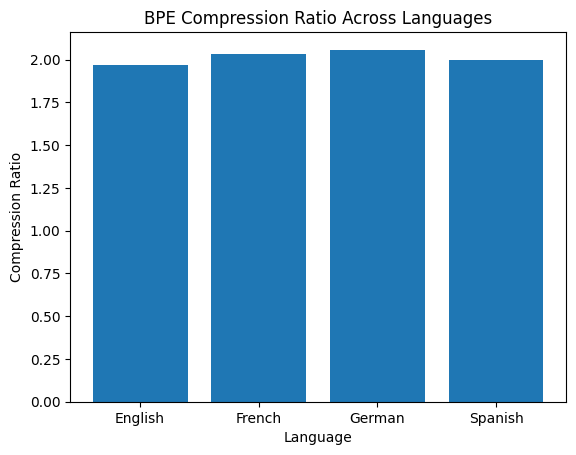

In [7]:
import matplotlib.pyplot as plt

plt.bar(bpe_df["Language"], bpe_df["Compression Ratio"])
plt.xlabel("Language")
plt.ylabel("Compression Ratio")
plt.title("BPE Compression Ratio Across Languages")
plt.show()

##Task 3: Bar plot for Comparison with GPT Tokenization Methods

In [8]:
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt

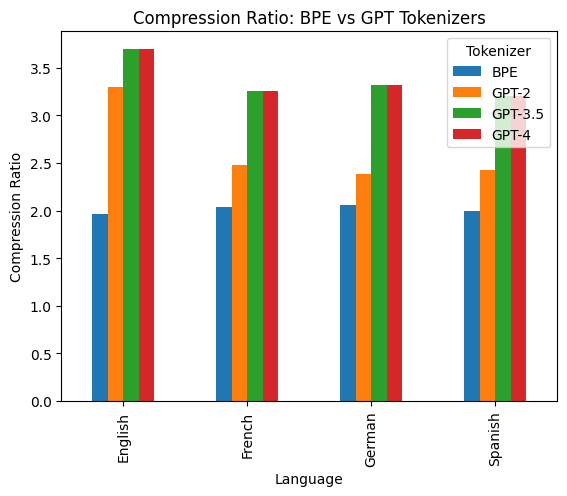

Tokenizer,BPE,GPT-2,GPT-3.5,GPT-4
Language,,,,
English,1.966197,3.299738,3.695450,3.695450
French,2.035547,2.474338,3.258564,3.258564
German,2.057817,2.388225,3.316439,3.316439
Spanish,1.998235,2.421583,3.199734,3.199734


In [9]:
def tiktoken_ratio(text, model):
    enc = tiktoken.encoding_for_model(model)
    return compression_ratio(text, len(enc.encode(text)))


model_map = {
    "GPT-2": "gpt2",
    "GPT-3.5": "gpt-3.5-turbo",
    "GPT-4": "gpt-4",
}

rows = []

for lang, text in texts.items():
    for name, model in model_map.items():
        rows.append({
            "Language": lang,
            "Tokenizer": name,
            "Compression Ratio": tiktoken_ratio(text, model)
        })

# Add BPE results
bpe_plot = bpe_df[["Language", "Compression Ratio"]].assign(Tokenizer="BPE")

comp_df = pd.concat([bpe_plot, pd.DataFrame(rows)], ignore_index=True)

comp_pivot = (
    comp_df
    .pivot(index="Language", columns="Tokenizer", values="Compression Ratio")
    .loc[["English", "French", "German", "Spanish"]]
)

comp_pivot.plot(kind="bar")
plt.xlabel("Language")
plt.ylabel("Compression Ratio")
plt.title("Compression Ratio: BPE vs GPT Tokenizers")
plt.show()

comp_pivot

## Task 4: Bar plot to compare compression ratios for BPE, GPT-2, GPT-5 and GPT-4 for all 4 languages

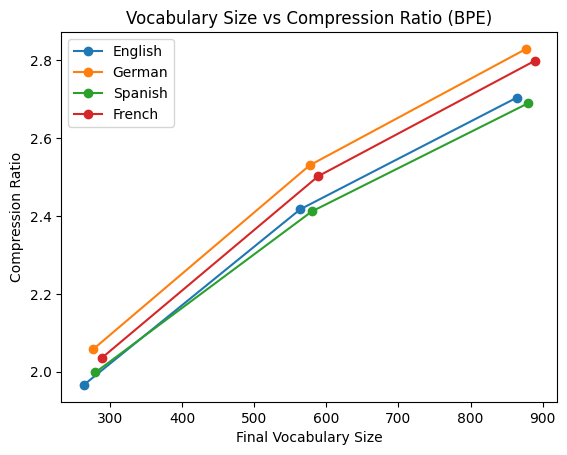

,Language,Final Vocab Size,Compression Ratio
0,English,264,1.966197
1,English,564,2.417098
2,English,864,2.703566
3,German,277,2.057817
4,German,577,2.529906
5,German,877,2.828756
6,Spanish,280,1.998235
7,Spanish,580,2.411536
8,Spanish,880,2.689481
9,French,289,2.035547


In [10]:
extra_tokens_list = [200, 500, 800]
rows = []

for lang, text in texts.items():
    for extra in extra_tokens_list:
        merges, vocab_size = learn_bpe(text, extra)
        rows.append({
            "Language": lang,
            "Final Vocab Size": vocab_size,
            "Compression Ratio": compression_ratio(text, bpe_token_count(text, merges))
        })

vocab_df = pd.DataFrame(rows)

for lang in vocab_df["Language"].unique():
    d = vocab_df[vocab_df["Language"] == lang]
    plt.plot(d["Final Vocab Size"], d["Compression Ratio"], marker="o", label=lang)

plt.xlabel("Final Vocabulary Size")
plt.ylabel("Compression Ratio")
plt.title("Vocabulary Size vs Compression Ratio (BPE)")
plt.legend()
plt.show()

vocab_df

## Task 5:  Effect of File Size on BPE Compression Ratio (only for English language).

- Text files with decreasing sizes using the scaling factors: 10, 8, 6.





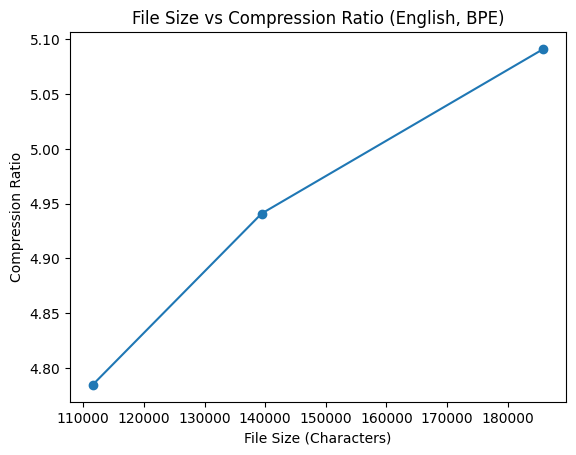

,Text Length,Final Vocab Size,Compression Ratio
0,111539,5636,4.784412
1,139424,7031,4.940960
2,185899,9355,5.091310


In [11]:
english = texts["English"]
factors = [10, 8, 6]
rows = []

for f in factors:
    text = english[:len(english) // f]
    extra = int(0.05 * len(text))
    merges, vocab_size = learn_bpe(text, extra)

    rows.append({
        "Text Length": len(text),
        "Final Vocab Size": vocab_size,
        "Compression Ratio": compression_ratio(text, bpe_token_count(text, merges))
    })

size_df = pd.DataFrame(rows).sort_values("Text Length")

plt.plot(size_df["Text Length"], size_df["Compression Ratio"], marker="o")
plt.xlabel("File Size (Characters)")
plt.ylabel("Compression Ratio")
plt.title("File Size vs Compression Ratio (English, BPE)")
plt.show()

size_df